## Customer Segmentation Analysis for E-Commerce

### Overview  

- Dataset: 2,205 customers, 39 features
- Has demographics, spending by category, purchase channels, campaign responses
- Goal: group customers into segments for targeted marketing

### Objectives  

- Explore and clean customer data
- Segment customers using K-Means clustering
- Visualize and interpret each segment

### Methodology  

- Data exploration and cleaning
- Feature selection and scaling
- Optimal cluster count, K-Means clustering
- Visualization (PCA, heatmaps)
- Business insights and recommendations

### Tools Used  

- pandas, numpy
- matplotlib, seaborn
- scikit-learn

In [14]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Display settings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [2]:
#Load dataset and check rows and columns.
df=pd.read_csv('ifood_df.csv')
df.shape

(2205, 39)

(2240, 29) means 2,240 customers and 29 columns of information about each one.

In [3]:
#first 5 rows of the dataset
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [4]:
# See all column names
print(df.columns.tolist())

['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow', 'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall']


In [5]:
df.dtypes    #tocheck datatypes

Income                  float64
Kidhome                   int64
Teenhome                  int64
Recency                   int64
MntWines                  int64
MntFruits                 int64
MntMeatProducts           int64
MntFishProducts           int64
MntSweetProducts          int64
MntGoldProds              int64
NumDealsPurchases         int64
NumWebPurchases           int64
NumCatalogPurchases       int64
NumStorePurchases         int64
NumWebVisitsMonth         int64
AcceptedCmp3              int64
AcceptedCmp4              int64
AcceptedCmp5              int64
AcceptedCmp1              int64
AcceptedCmp2              int64
Complain                  int64
Z_CostContact             int64
Z_Revenue                 int64
Response                  int64
Age                       int64
Customer_Days             int64
marital_Divorced          int64
marital_Married           int64
marital_Single            int64
marital_Together          int64
marital_Widow             int64
educatio

In [6]:
## Complete overview — column names, data types, and non-null counts
df.info

<bound method DataFrame.info of        Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
0     58138.0        0         0       58       635         88   
1     46344.0        1         1       38        11          1   
2     71613.0        0         0       26       426         49   
3     26646.0        1         0       26        11          4   
4     58293.0        1         0       94       173         43   
...       ...      ...       ...      ...       ...        ...   
2200  61223.0        0         1       46       709         43   
2201  64014.0        2         1       56       406          0   
2202  56981.0        0         0       91       908         48   
2203  69245.0        0         1        8       428         30   
2204  52869.0        1         1       40        84          3   

      MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  ...  \
0                 546              172                88            88  ...   
1                

### **Data Exploration**
Before doing any analysis, understand what our data contains —
what each column means, what the numbers look like, and whether anything looks unusual.

In [7]:
#statistical summary
df.describe().T               #T for transpose ,flips rows and column

,count,mean,std,min,25%,50%,75%,max
Income,2205.0,51622.094785,20713.063826,1730.0,35196.0,51287.0,68281.0,113734.0
Kidhome,2205.0,0.442177,0.537132,0.0,0.0,0.0,1.0,2.0
Teenhome,2205.0,0.506576,0.544380,0.0,0.0,0.0,1.0,2.0
Recency,2205.0,49.009070,28.932111,0.0,24.0,49.0,74.0,99.0
MntWines,2205.0,306.164626,337.493839,0.0,24.0,178.0,507.0,1493.0
MntFruits,2205.0,26.403175,39.784484,0.0,2.0,8.0,33.0,199.0
MntMeatProducts,2205.0,165.312018,217.784507,0.0,16.0,68.0,232.0,1725.0
MntFishProducts,2205.0,37.756463,54.824635,0.0,3.0,12.0,50.0,259.0
MntSweetProducts,2205.0,27.128345,41.130468,0.0,1.0,8.0,34.0,262.0
MntGoldProds,2205.0,44.057143,51.736211,0.0,9.0,25.0,56.0,321.0


If min is negative or max is extremely far from mean, that's an outlier. For example if Income has a mean of 50000 but max of 9999999, something is wrong.

In [8]:
#check for duplicated rows
df.duplicated().sum()

np.int64(184)

### **Explore spending columns**  
  
  Mnt stands for Amount spent on. These are your most important columns for segmentation — they directly show customer buying behavior. Sorting by mean tells you which product category customers spend most on overall.

In [9]:
# Identify spending columns (columns starting with 'Mnt')
spend_cols = [col for col in df.columns if 'Mnt' in col]
print("Spending columns:", spend_cols)

# See their averages
df[spend_cols].mean().sort_values(ascending=False)

Spending columns: ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'MntTotal', 'MntRegularProds']


MntTotal            562.764626
MntRegularProds     518.707483
MntWines            306.164626
MntMeatProducts     165.312018
MntGoldProds         44.057143
MntFishProducts      37.756463
MntSweetProducts     27.128345
MntFruits            26.403175
dtype: float64

### **Explore purchase column channel**  
  Num columns tell you how customers shop — web, store, catalogue, deals. This reveals channel preferences per segment later.

In [10]:
# Identify purchase channel columns
purchase_cols = [col for col in df.columns if 'Num' in col]
print("Purchase channel columns:", purchase_cols)

df[purchase_cols].mean().sort_values(ascending=False)

Purchase channel columns: ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']


NumStorePurchases      5.823583
NumWebVisitsMonth      5.336961
NumWebPurchases        4.100680
NumCatalogPurchases    2.645351
NumDealsPurchases      2.318367
dtype: float64

### **Check unique values**  
  
  K-Means only works with numbers,  need to know what text columns exist and what values they hold. For example Education might have values like 'Graduation', 'PhD', 'Master' these need to be converted to numbers before clustering.

In [11]:
# Find all text/categorical columns
cat_cols = df.select_dtypes(include='object').columns
print("Categorical columns:", cat_cols.tolist())

# See unique values in each
for col in cat_cols:
    print(f"\n{col}: {df[col].unique()}")

Categorical columns: []


In [12]:
# Print all 39 column names neatly
for i, col in enumerate(df.columns):
    print(f"{i+1:02d}. {col}")

01. Income
02. Kidhome
03. Teenhome
04. Recency
05. MntWines
06. MntFruits
07. MntMeatProducts
08. MntFishProducts
09. MntSweetProducts
10. MntGoldProds
11. NumDealsPurchases
12. NumWebPurchases
13. NumCatalogPurchases
14. NumStorePurchases
15. NumWebVisitsMonth
16. AcceptedCmp3
17. AcceptedCmp4
18. AcceptedCmp5
19. AcceptedCmp1
20. AcceptedCmp2
21. Complain
22. Z_CostContact
23. Z_Revenue
24. Response
25. Age
26. Customer_Days
27. marital_Divorced
28. marital_Married
29. marital_Single
30. marital_Together
31. marital_Widow
32. education_2n Cycle
33. education_Basic
34. education_Graduation
35. education_Master
36. education_PhD
37. MntTotal
38. MntRegularProds
39. AcceptedCmpOverall


### **Feature Selection and Scaling**
We handpick columns that best represent customer behavior.
Then we scale them so that no single feature dominates the clustering due to its size.

In [13]:
features = [
    'Income',           # Customer wealth
    'Recency',          # How recently they purchased
    'MntTotal',         # Total spending (all categories)
    'MntWines',         # Spending on wines
    'MntMeatProducts',  # Spending on meat
    'NumStorePurchases',# Prefers store shopping?
    'NumWebPurchases',  # Prefers web shopping?
    'NumCatalogPurchases', # Prefers catalog?
    'NumDealsPurchases',# Deal-seeker behavior
    'AcceptedCmpOverall', # Total campaigns accepted
    'Age',              # Customer age
    'Kidhome',          # Has kids?
    'Teenhome'          # Has teenagers?
]

X = df[features].copy()
print(f"Feature matrix shape: {X.shape}")
print(X.head())

Feature matrix shape: (2205, 13)
    Income  Recency  MntTotal  MntWines  MntMeatProducts  NumStorePurchases  \
0  58138.0       58      1529       635              546                  4   
1  46344.0       38        21        11                6                  2   
2  71613.0       26       734       426              127                 10   
3  26646.0       26        48        11               20                  4   
4  58293.0       94       407       173              118                  6   

   NumWebPurchases  NumCatalogPurchases  NumDealsPurchases  \
0                8                   10                  3   
1                1                    1                  2   
2                8                    2                  1   
3                2                    0                  2   
4                5                    3                  5   

   AcceptedCmpOverall  Age  Kidhome  Teenhome  
0                   0   63        0         0  
1                   0  

In [15]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling - Income mean:", X['Income'].mean().round(2))
print("After scaling  - Income mean:", X_scaled[:, 0].mean().round(4))
print("After scaling  - Income std: ", X_scaled[:, 0].std().round(4))

Before scaling - Income mean: 51622.09
After scaling  - Income mean: 0.0
After scaling  - Income std:  1.0


Without scaling, K-Means will think Income is 56,000x more important than Kidhome just because its numbers are bigger. 


### **Finding the Optimal Number of Clusters (Elbow Method)**
K-Means requires us to specify "k" — the number of clusters — in advance.
We use the Elbow Method to find the best value of k by testing multiple values
and measuring how "tight" the clusters are.

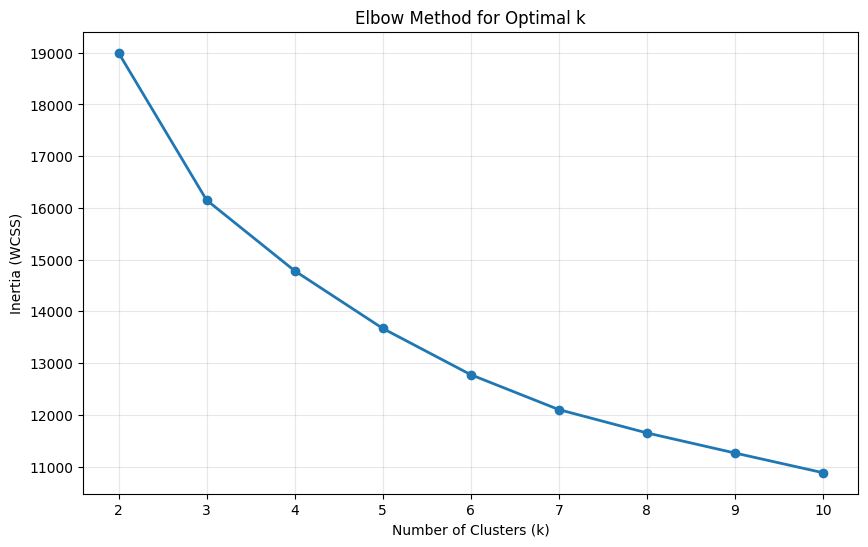

In [16]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

inertia_ = Within-Cluster Sum of Squares (WCSS) = how far, on average, each point is from its cluster's center.

- With k=2, clusters are big and loose → high inertia
- With k=2205 (one cluster per customer), inertia = 0, but that's useless — every customer is their "own segment"

k=2: Silhouette Score = 0.3130
k=3: Silhouette Score = 0.2576
k=4: Silhouette Score = 0.1923
k=5: Silhouette Score = 0.1893
k=6: Silhouette Score = 0.1960
k=7: Silhouette Score = 0.1916
k=8: Silhouette Score = 0.1821
k=9: Silhouette Score = 0.1772
k=10: Silhouette Score = 0.1554


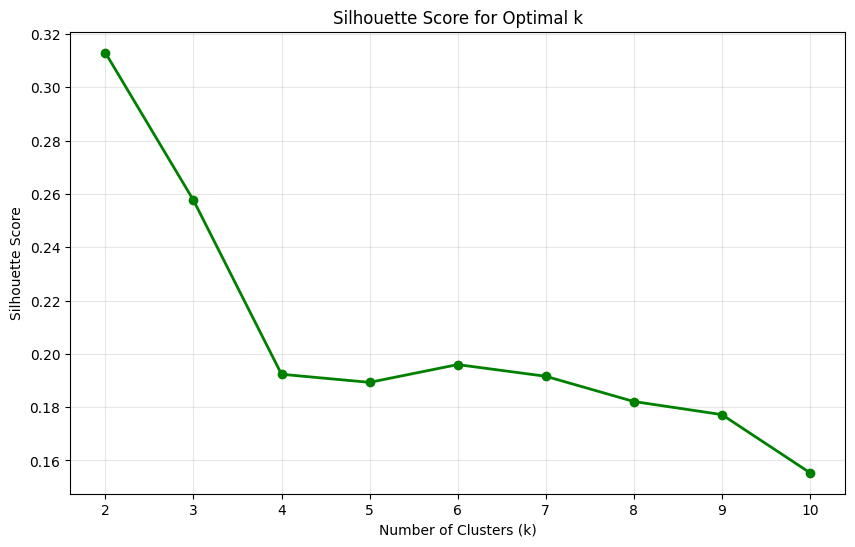

In [17]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o', color='green', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

Why a second method? The elbow can be subjective — sometimes the "bend" isn't obvious. The Silhouette Score gives a number between -1 and 1

### Final K-Means Model (k=4)
Based on the elbow method and silhouette analysis, we select k=4.

k=4 sits at the elbow bend and provides interpretable, distinct customer segments.

In [18]:
# Fit final K-Means model with k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print("Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())

Cluster distribution:
Cluster
0    490
1    538
2    589
3    588
Name: count, dtype: int64


### **Visualizing the Clusters**
Since we used 13 features, we can't directly plot in 13 dimensions.
We use PCA (Principal Component Analysis) to compress these features into 2 dimensions


In [19]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

df['PC1'] = pca_components[:, 0]
df['PC2'] = pca_components[:, 1]

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

Variance explained by PC1: 42.64%
Variance explained by PC2: 13.93%
Total variance explained: 56.57%


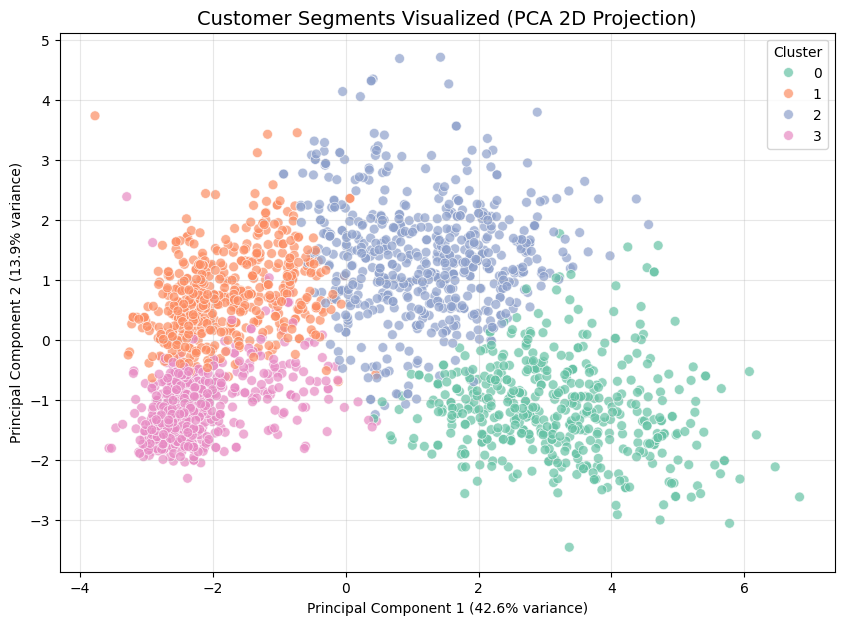

In [20]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df, x='PC1', y='PC2',
    hue='Cluster', palette='Set2',
    s=50, alpha=0.7
)
plt.title('Customer Segments Visualized (PCA 2D Projection)', fontsize=14)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

If PC1+PC2 explain 60%, it means your 2D plot captures 60% of the real differences between customers

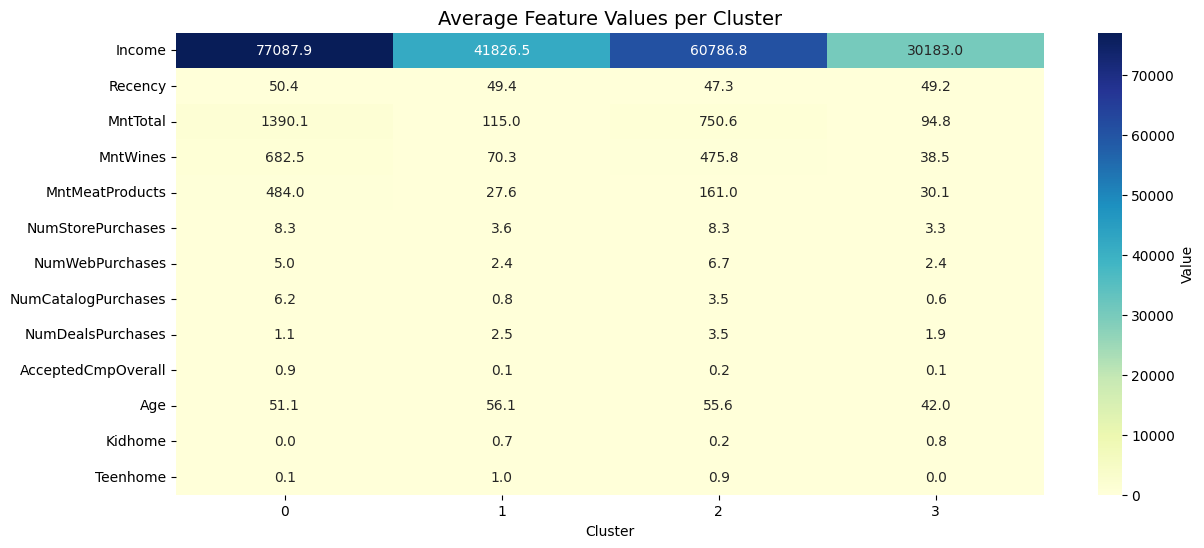

,Income,Recency,MntTotal,MntWines,MntMeatProducts,NumStorePurchases,NumWebPurchases,NumCatalogPurchases,NumDealsPurchases,AcceptedCmpOverall,Age,Kidhome,Teenhome
Cluster,,,,,,,,,,,,,
0,77087.86,50.44,1390.14,682.46,483.99,8.26,4.98,6.20,1.12,0.88,51.12,0.04,0.08
1,41826.51,49.41,114.96,70.26,27.58,3.65,2.37,0.75,2.51,0.08,56.10,0.69,1.00
2,60786.77,47.28,750.63,475.78,160.96,8.34,6.69,3.47,3.53,0.23,55.60,0.16,0.92
3,30182.99,49.18,94.82,38.53,30.13,3.26,2.36,0.60,1.93,0.09,41.98,0.83,0.00


In [21]:
# Calculate mean values for each feature, per cluster
cluster_profile = df.groupby('Cluster')[features].mean().round(2)

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_profile.T, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Value'})
plt.title('Average Feature Values per Cluster', fontsize=14)
plt.xlabel('Cluster')
plt.show()

cluster_profile

### Naming the Segments and Business Insights
Using the cluster profile heatmap, we interpret each cluster's characteristics
and translate them into actionable marketing personas.

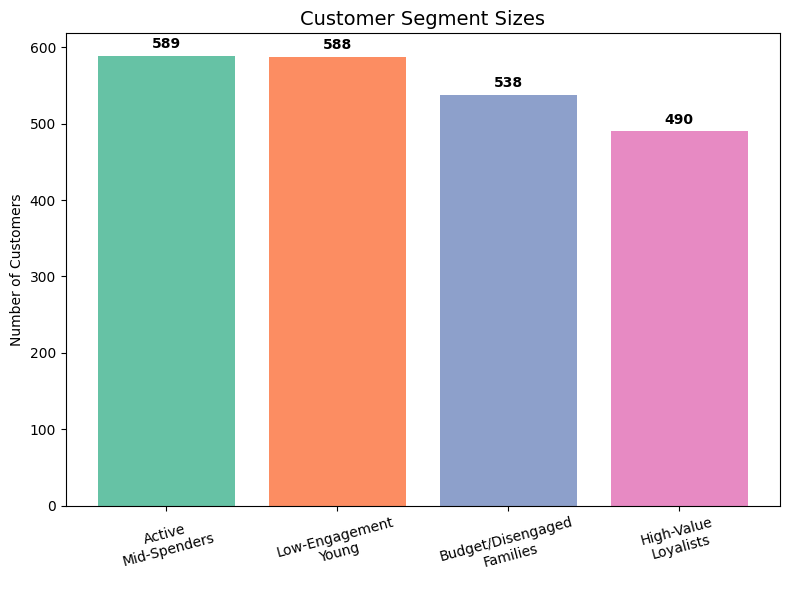

In [22]:
plt.figure(figsize=(8, 6))
cluster_names = {
    0: 'High-Value\nLoyalists',
    1: 'Budget/Disengaged\nFamilies',
    2: 'Active\nMid-Spenders',
    3: 'Low-Engagement\nYoung'
}
df['Segment'] = df['Cluster'].map(cluster_names)

segment_counts = df['Segment'].value_counts()
colors = sns.color_palette('Set2', 4)
plt.bar(segment_counts.index, segment_counts.values, color=colors)
plt.title('Customer Segment Sizes', fontsize=14)
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
for i, v in enumerate(segment_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

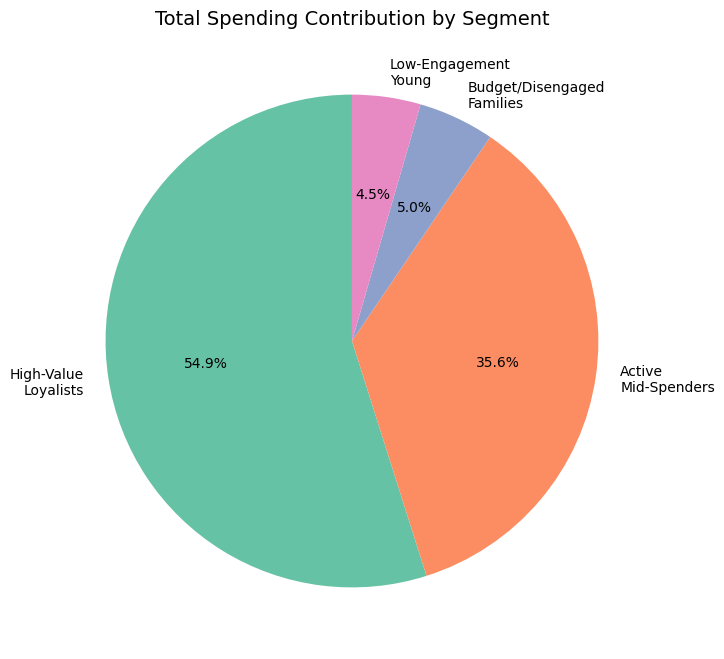

Segment
High-Value\nLoyalists          681168
Active\nMid-Spenders           442123
Budget/Disengaged\nFamilies     61849
Low-Engagement\nYoung           55756
Name: MntTotal, dtype: int64

Total revenue: $1,240,896.00


In [23]:
revenue_by_segment = df.groupby('Segment')['MntTotal'].sum().sort_values(ascending=False)
total_revenue = revenue_by_segment.sum()

plt.figure(figsize=(8, 8))
plt.pie(revenue_by_segment, labels=revenue_by_segment.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2', 4), startangle=90)
plt.title('Total Spending Contribution by Segment', fontsize=14)
plt.show()

print(revenue_by_segment)
print(f"\nTotal revenue: ${total_revenue:,.2f}")

### **Final Recommendations**

**Segment 0 – High-Value Loyalists** (22%)  
VIP loyalty program, premium bundles, early access, retention priority  

**Segment 1 – Budget Families** (24%)  
Discount campaigns, family bundles, deal alerts  

**Segment 2 – Active Mid-Spenders** (27%)  
Cross-channel promotions, personalized recommendations, upsell opportunity  

**Segment 3 – Low-Engagement Young** (27%)  
Onboarding incentives, social media campaigns, entry-level bundles, re-engagement